# Exploratory Data Analysis — UCI Drug Consumption Dataset (Raw)

This notebook explores the raw UCI dataset before encoding, examining feature distributions, class balance across drug types, and relationships between personality traits and drug use.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ALL_COLS = [
    'ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity',
    'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS',
    'Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc',
    'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD',
    'Meth', 'Mushrooms', 'Nicotine', 'Semer', 'VSA'
]

df = pd.read_csv('/Users/tg197682/Downloads/Computer Science Year 3/COMP3931_Individual_Project/student-addiction-risk-prediction/data/raw/drug_consumption.data', header=None, names=ALL_COLS)

print(df.shape)
display(df.head())
print(df.columns.tolist())
print(df.isnull().sum())
print(df.describe(include='all'))

(1885, 32)


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS', 'Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms', 'Nicotine', 'Semer', 'VSA']
ID           0
Age          0
Gender       0
Education    0
Country      0
Ethnicity    0
Nscore       0
Escore       0
Oscore       0
Ascore       0
Cscore       0
Impulsive    0
SS           0
Alcohol      0
Amphet       0
Amyl         0
Benzos       0
Caff         0
Cannabis     0
Choc         0
Coke         0
Crack        0
Ecstasy      0
Heroin       0
Ketamine     0
Legalh       0
LSD          0
Meth         0
Mushrooms    0
Nicotine     0
Semer        0
VSA          0
dtype: int64
                 ID         Age       Gender    Education      Country  \
count   1885.000000  1885.00000  1885.000000  1885.000000  1885.000000   
unique          NaN         NaN          NaN  

/var/folders/57/yz44gjt978384yz4z8qjnm8w0000gn/T/ipykernel_27243/3232823799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cannabis', data=df, order=['CL0','CL1','CL2','CL3','CL4','CL5','CL6'],


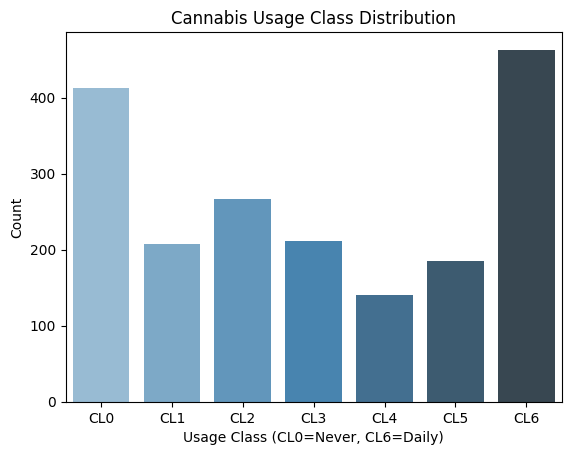

Cannabis
CL0    413
CL1    207
CL2    266
CL3    211
CL4    140
CL5    185
CL6    463
Name: count, dtype: int64


In [2]:
# Cannabis class distribution — our chosen target variable
sns.countplot(x='Cannabis', data=df, order=['CL0','CL1','CL2','CL3','CL4','CL5','CL6'],
              palette='Blues_d')
plt.title('Cannabis Usage Class Distribution')
plt.xlabel('Usage Class (CL0=Never, CL6=Daily)')
plt.ylabel('Count')
plt.show()

print(df['Cannabis'].value_counts().sort_index())

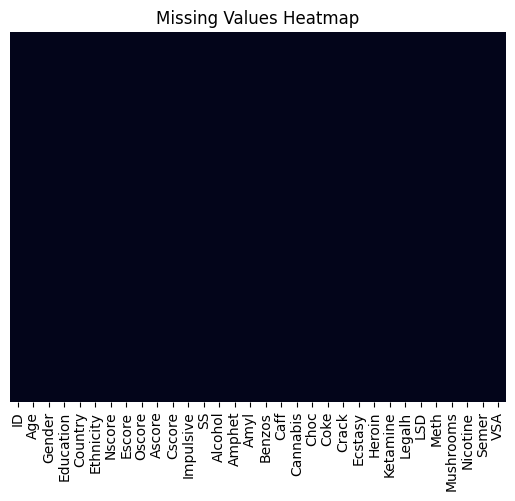

In [3]:
# Missing values heatmap
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

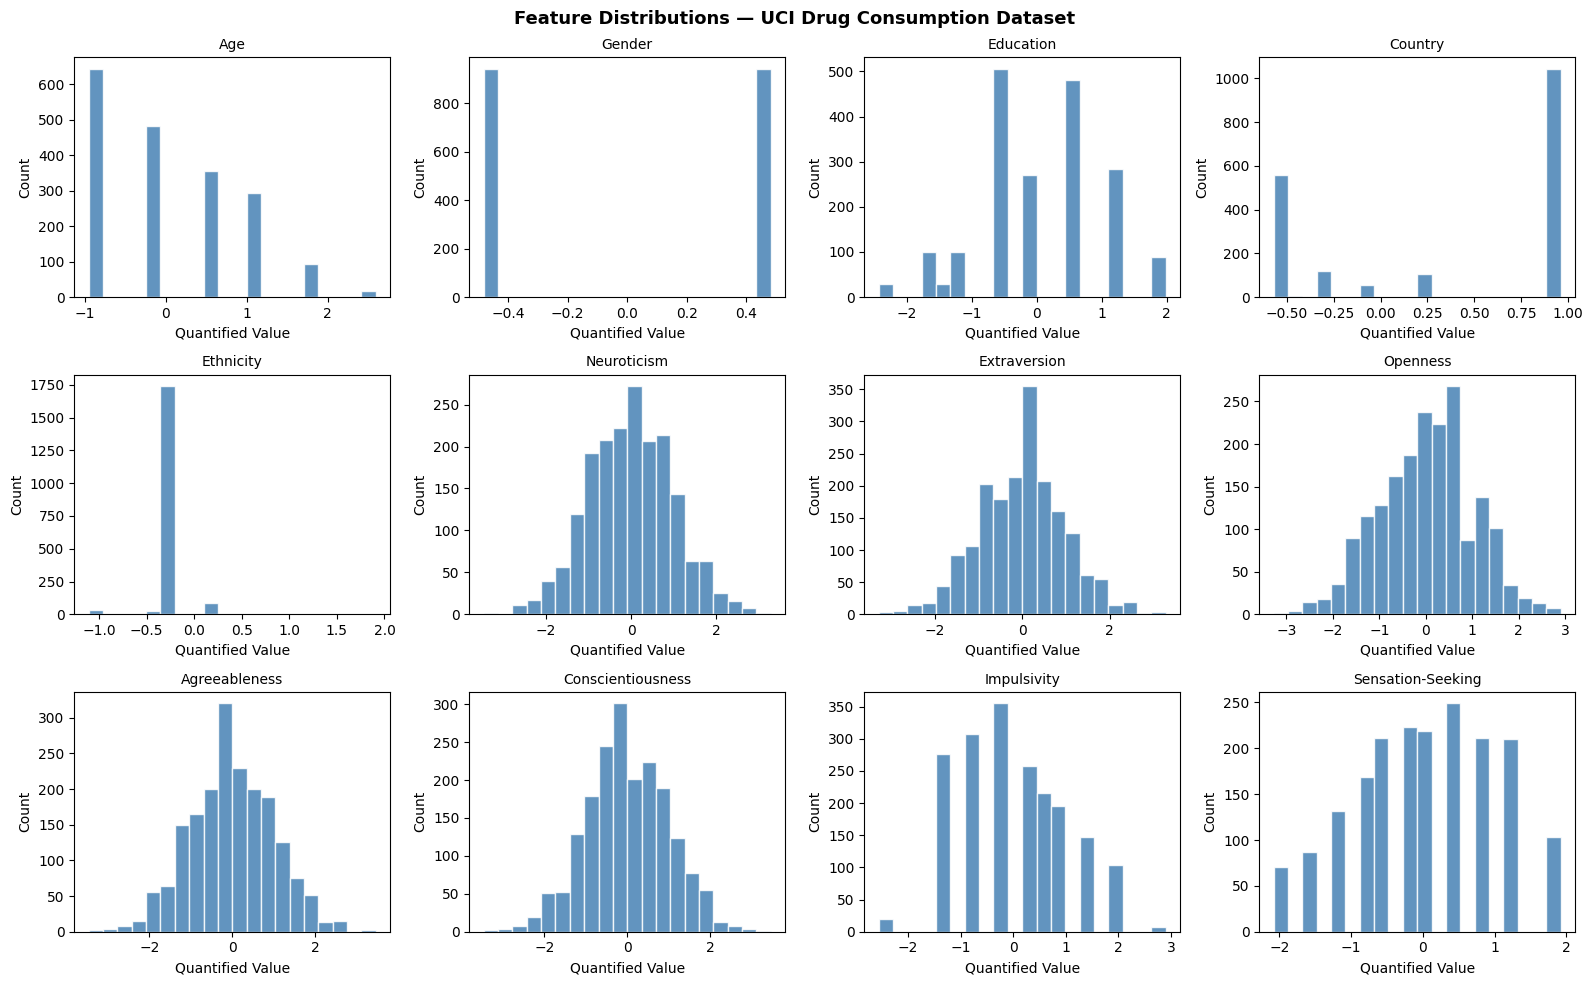

In [4]:
# Distribution of all 12 personality/demographic features
FEATURE_COLS = ['Age','Gender','Education','Country','Ethnicity',
                'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']
FEATURE_LABELS = ['Age','Gender','Education','Country','Ethnicity',
                  'Neuroticism','Extraversion','Openness',
                  'Agreeableness','Conscientiousness','Impulsivity','Sensation-Seeking']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, (col, label) in enumerate(zip(FEATURE_COLS, FEATURE_LABELS)):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Quantified Value')
    axes[i].set_ylabel('Count')
fig.suptitle('Feature Distributions — UCI Drug Consumption Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

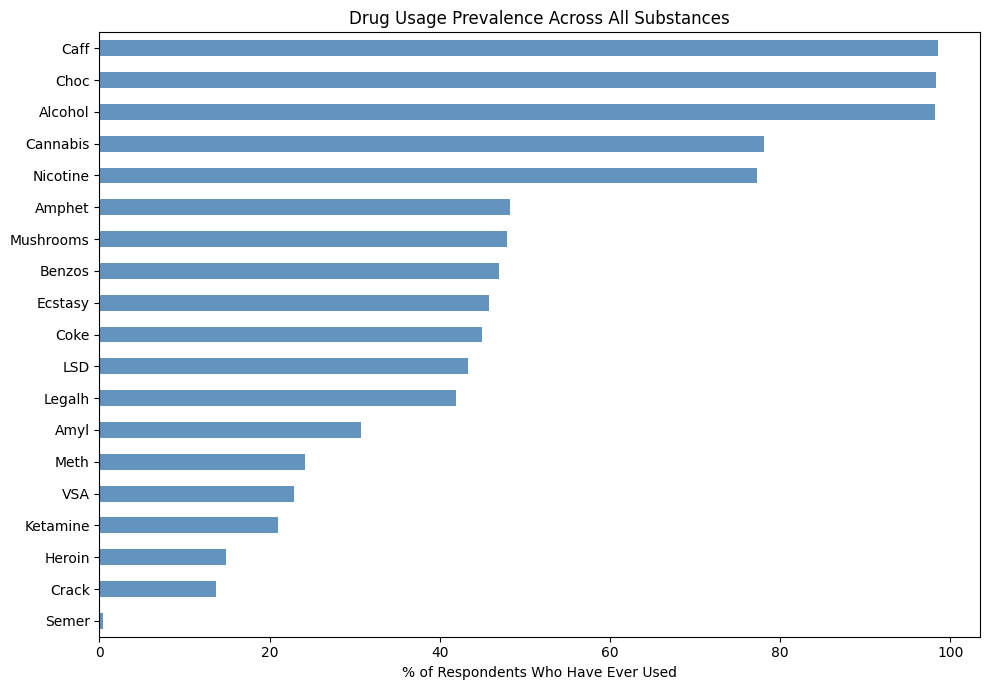

In [5]:
# Usage rate across all 18 drugs (% of respondents who have ever used)
DRUG_COLS = ['Alcohol','Amphet','Amyl','Benzos','Caff','Cannabis','Choc',
             'Coke','Crack','Ecstasy','Heroin','Ketamine','Legalh','LSD',
             'Meth','Mushrooms','Nicotine','Semer','VSA']

ever_used = {d: (df[d] != 'CL0').mean() * 100 for d in DRUG_COLS}
ever_used_s = pd.Series(ever_used).sort_values(ascending=True)

ever_used_s.plot(kind='barh', figsize=(10, 7), color='steelblue', alpha=0.85)
plt.xlabel('% of Respondents Who Have Ever Used')
plt.title('Drug Usage Prevalence Across All Substances')
plt.tight_layout()
plt.show()

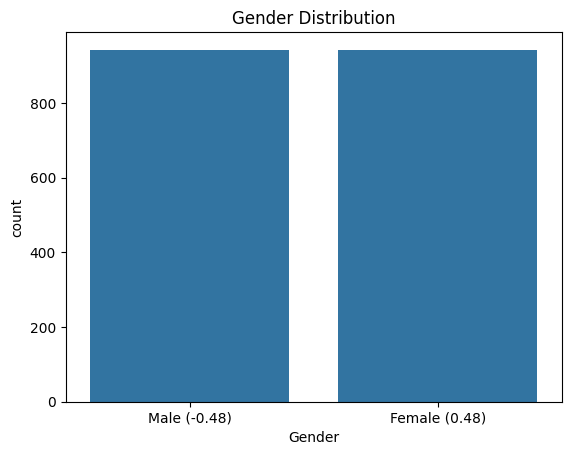

Gender
-0.48246    943
 0.48246    942
Name: count, dtype: int64


In [6]:
# Gender distribution
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xticks([0, 1], ['Male (-0.48)', 'Female (0.48)'])
plt.show()

print(df['Gender'].value_counts())

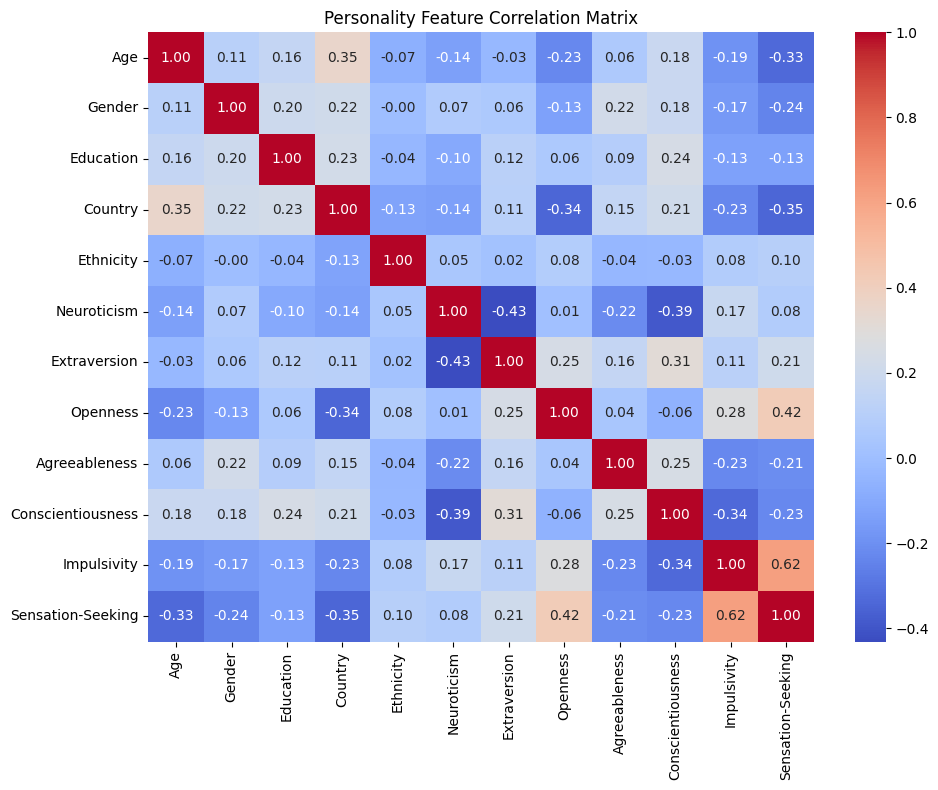

In [7]:
# Correlation heatmap of personality features
corr = df[FEATURE_COLS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=FEATURE_LABELS, yticklabels=FEATURE_LABELS)
plt.title('Personality Feature Correlation Matrix')
plt.tight_layout()
plt.show()

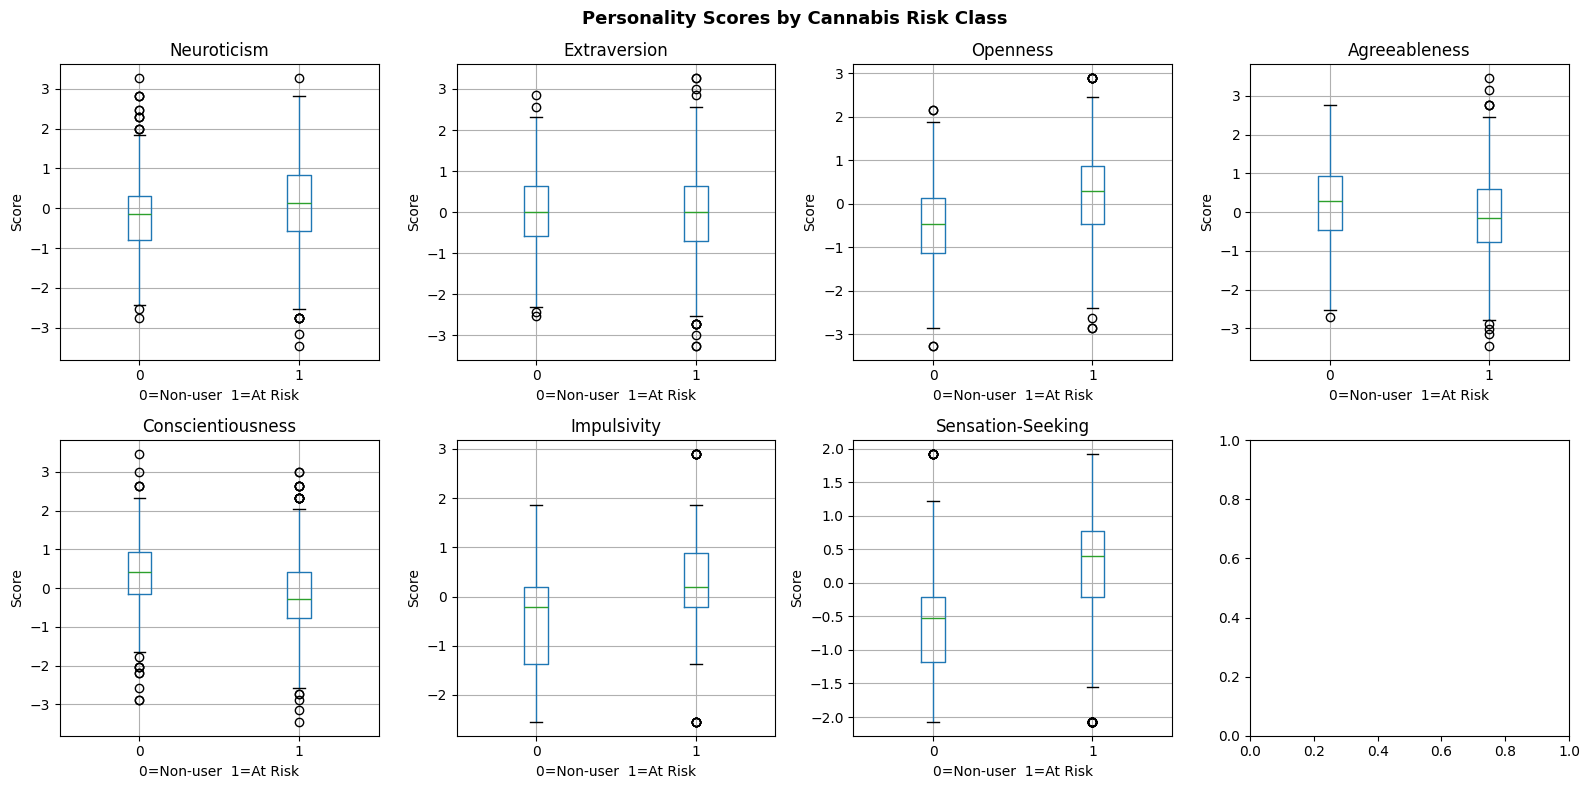

In [8]:
# Binary cannabis target vs personality scores (boxplots)
df['cannabis_binary'] = df['Cannabis'].apply(lambda x: 0 if x in ['CL0','CL1'] else 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
personality_cols = ['Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']
personality_labels = ['Neuroticism','Extraversion','Openness','Agreeableness',
                      'Conscientiousness','Impulsivity','Sensation-Seeking']

for i, (col, label) in enumerate(zip(personality_cols, personality_labels)):
    df.boxplot(column=col, by='cannabis_binary', ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xlabel('0=Non-user  1=At Risk')
    axes[i].set_ylabel('Score')

fig.suptitle('Personality Scores by Cannabis Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()